# GAM (Generalized Additive Model) Pipeline — Trajectory Prediction Metrics

This notebook implements a complete GAM pipeline for analysing how agent motion and scene context features affect trajectory prediction quality (ADE/FDE), including:
- Distribution checks for features and target
- Correlation analysis (linear and non-linear)
- Feature selection (removing highly correlated features)
- Log transformation of the target (if right-skewed)
- Feature standardization
- Linear GAM fitting and evaluation
- Alternative GAM setups (e.g., GammaGAM)
- Removal of non-significant features
- Refitting on selected features
- Final evaluation and comparison

## 1. Import Required Libraries

In [10]:
# Core libraries
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution checks
from scipy import stats
from scipy.stats import skew, shapiro

# Preprocessing and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import mutual_info_regression

# GAM models
from pygam import LinearGAM, GammaGAM, s, f, l

# Settings
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load and Inspect the Dataset

Load the trajectory prediction evaluation metrics CSV produced by the Trajectron++ pipeline. Each row represents one agent trajectory with motion features, scene context features, and prediction error metrics.

In [11]:
# ── Configure paths ──────────────────────────────────────────────────────────
# Adjust this path to point to your eval_epoch CSV
model_name = "nusc_mini_debug_tpp-11_Mar_2026_15_29_02"
CSV_PATH = Path("../../results/trajectory_prediction/trajectory_metrics_joined/"
                f"{model_name}/eval_epoch_5.csv")

SAVE_DIR = Path("../../results/interpretable_model/gam/plots")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Load the dataset
df = pd.read_csv(CSV_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\n{'='*60}")
print("First 5 rows:")
df.head()

Dataset shape: (451, 41)

First 5 rows:


,data_idx,ml_ade,ml_fde,min_ade_5,nll_mean,nll_final,mean_speed,max_speed,std_speed,mean_acceleration,...,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,scene_density_PEDESTRIAN,scene_num_BICYCLE,scene_density_BICYCLE,scene_num_MOTORCYCLE,scene_density_MOTORCYCLE
0,329,0.914857,3.197555,0.915371,2.867357,10.152276,0.962106,1.230403,0.116722,0.056417,...,1160.377375,40.869190,28.392473,0.014650,0.005171,0.009480,NaN,NaN,NaN,NaN
1,190,0.151084,0.312564,0.087302,-1.594040,-1.285830,0.085898,0.218477,0.063105,0.007725,...,1160.377375,40.869190,28.392473,0.014650,0.005171,0.009480,NaN,NaN,NaN,NaN
2,420,0.475158,0.833887,0.426153,3.946011,5.647027,0.218623,0.383437,0.099171,0.031384,...,1821.083675,44.533135,40.892780,0.027456,0.012630,0.010433,NaN,NaN,8.0,0.004393
3,131,1.275023,3.326790,0.769307,2.154090,7.083624,1.233457,1.483624,0.190256,0.051802,...,1230.401053,43.391608,28.355738,0.013004,0.005689,0.007315,NaN,NaN,NaN,NaN
4,191,0.172736,0.389740,0.078058,-1.785440,-0.578248,0.091226,0.218477,0.064457,0.010995,...,1057.088774,37.340273,28.309616,0.014190,0.005676,0.008514,NaN,NaN,NaN,NaN


In [12]:
# Data types and missing values
print("Dataset Info:")
print(f"{'='*60}")
df.info()
print(f"\n{'='*60}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   data_idx                  451 non-null    int64  
 1   ml_ade                    451 non-null    float64
 2   ml_fde                    451 non-null    float64
 3   min_ade_5                 451 non-null    float64
 4   nll_mean                  451 non-null    float64
 5   nll_final                 451 non-null    float64
 6   mean_speed                451 non-null    float64
 7   max_speed                 451 non-null    float64
 8   std_speed                 451 non-null    float64
 9   mean_acceleration         451 non-null    float64
 10  max_acceleration          451 non-null    float64
 11  mean_jerk                 451 non-null    float64
 12  max_jerk                  451 non-null    float64
 13  duration                  451 non-null    float64
 

In [13]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,data_idx,ml_ade,ml_fde,min_ade_5,nll_mean,nll_final,mean_speed,max_speed,std_speed,mean_acceleration,...,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,scene_density_PEDESTRIAN,scene_num_BICYCLE,scene_density_BICYCLE,scene_num_MOTORCYCLE,scene_density_MOTORCYCLE
count,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,...,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,30.0,30.000000,67.000000,67.000000
mean,225.000000,0.795241,1.714137,0.651478,1.615489,4.358871,1.047268,1.255228,0.139951,0.013555,...,1370.663233,40.175802,33.639475,0.017466,0.005686,0.011310,2.0,0.001196,5.000000,0.002631
std,130.336743,0.582555,1.354286,0.568139,2.628688,4.216529,0.476805,0.503591,0.104514,0.047515,...,459.222736,5.788054,8.415139,0.004751,0.002103,0.005078,0.0,0.000032,2.443296,0.001281
min,0.000000,0.029572,0.042517,0.024698,-3.505121,-2.427706,0.000000,0.000000,0.000000,-0.202674,...,776.025388,26.965117,23.491130,0.009868,0.002880,0.003920,2.0,0.001164,2.000000,0.001164
25%,112.500000,0.353661,0.701191,0.246380,0.210995,2.004534,0.863279,1.230403,0.071290,-0.007716,...,1007.260160,36.739884,28.333285,0.013504,0.003866,0.007502,2.0,0.001164,3.000000,0.001684
50%,225.000000,0.671298,1.385031,0.506425,1.107724,3.378124,1.226409,1.395103,0.114736,0.005237,...,1187.889506,40.145465,28.803449,0.017126,0.005676,0.011641,2.0,0.001196,5.000000,0.002602
75%,337.500000,1.079434,2.312771,0.852741,2.484541,5.534409,1.363743,1.564261,0.183586,0.030841,...,1841.250853,44.443819,43.279501,0.021330,0.007284,0.015012,2.0,0.001227,8.000000,0.003539
max,450.000000,3.694747,7.312213,3.529320,14.007240,20.000000,1.627962,2.048388,0.582534,0.183462,...,2260.842272,51.971918,48.085698,0.036208,0.017735,0.021173,2.0,0.001227,8.000000,0.005912


In [14]:
# ── Define target and feature columns ─────────────────────────────────────────
# Target: trajectory prediction error metric
target_col = "ml_ade"  # Change to 'ml_fde', 'min_ade_5', etc. as needed

# Auto-detect from common target names if not found
potential_targets = [
    "ml_ade", "ml_fde", "min_ade_5", "min_fde_5",
    "ade", "fde", "minADE", "minFDE", "min_ade", "min_fde",
    "brier_fde", "nll", "miss_rate",
]
if target_col not in df.columns:
    for col in potential_targets:
        if col in df.columns:
            target_col = col
            break

assert target_col in df.columns, f"Target '{target_col}' not found. Available: {df.columns.tolist()}"
print(f"Target variable: {target_col}")

# Agent motion & scene context features
FEATURE_CANDIDATES = [
    # Agent motion features
    'mean_speed', 'max_speed', 'std_speed',
    'mean_acceleration', 'max_acceleration',
    'mean_jerk', 'max_jerk',
    'path_efficiency', 'displacement', 'path_length',
    'heading_change', 'has_collision', 'min_neighbor_distance',
    # Scene context features
    'scene_num_agents', 'scene_num_VEHICLE',
    'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height',
    'scene_spatial_density', 'scene_density_VEHICLE',
]

# Keep only features that actually exist in the data
numerical_cols = [c for c in FEATURE_CANDIDATES if c in df.columns and np.issubdtype(df[c].dtype, np.number)]

# Identify any categorical columns among the features (e.g., agent type)
categorical_cols = [c for c in df.columns if df[c].dtype == 'object' or df[c].dtype.name == 'category']
# Exclude ID-like columns
exclude_patterns = ['instance', 'id', 'idx', 'name']
categorical_cols = [c for c in categorical_cols if not any(p in c.lower() for p in exclude_patterns)]

print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Target variable: ml_ade

Numerical features (20): ['mean_speed', 'max_speed', 'std_speed', 'mean_acceleration', 'max_acceleration', 'mean_jerk', 'max_jerk', 'path_efficiency', 'displacement', 'path_length', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_num_VEHICLE', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE']
Categorical features (2): ['agent_type', 'scene_path']


## 3. Check Distribution of Features and Target

Plot histograms and KDE plots for all numerical features, with special attention to the trajectory error target. Assess skewness to determine whether log transformation is needed.

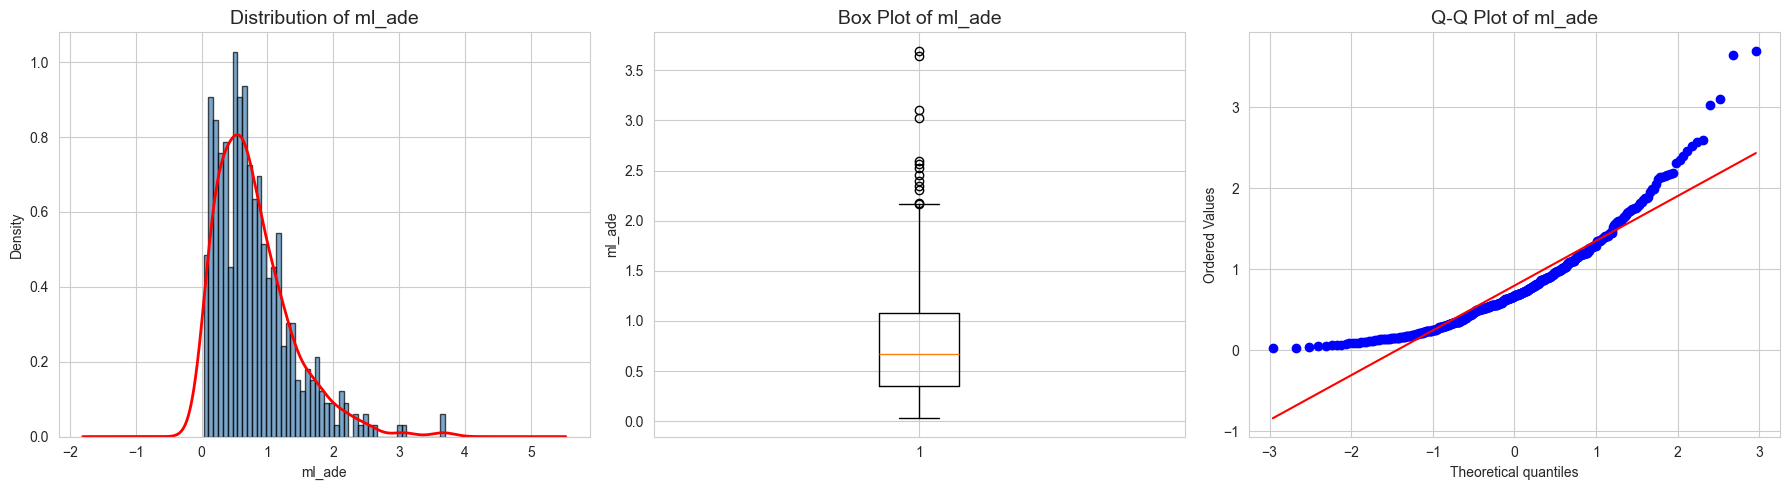


Target 'ml_ade' statistics:
  Skewness:  1.4600
  Kurtosis:  3.1145
  → Target is RIGHT-SKEWED (skewness > 1). Log transformation recommended.
    (Common for ADE/FDE — error distributions are typically right-skewed)


In [15]:
# Distribution of the target variable (prediction error metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
axes[0].hist(df[target_col].dropna(), bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="black")
df[target_col].dropna().plot.kde(ax=axes[0], color="red", linewidth=2)
axes[0].set_title(f"Distribution of {target_col}", fontsize=14)
axes[0].set_xlabel(target_col)
axes[0].set_ylabel("Density")

# Box plot
axes[1].boxplot(df[target_col].dropna(), vert=True)
axes[1].set_title(f"Box Plot of {target_col}", fontsize=14)
axes[1].set_ylabel(target_col)

# Q-Q plot
stats.probplot(df[target_col].dropna(), dist="norm", plot=axes[2])
axes[2].set_title(f"Q-Q Plot of {target_col}", fontsize=14)

plt.tight_layout()
plt.savefig(SAVE_DIR / f"target_distribution_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

# Skewness and kurtosis
target_skewness = skew(df[target_col].dropna())
target_kurtosis = stats.kurtosis(df[target_col].dropna())
print(f"\nTarget '{target_col}' statistics:")
print(f"  Skewness:  {target_skewness:.4f}")
print(f"  Kurtosis:  {target_kurtosis:.4f}")

if target_skewness > 1:
    print(f"  → Target is RIGHT-SKEWED (skewness > 1). Log transformation recommended.")
    print(f"    (Common for ADE/FDE — error distributions are typically right-skewed)")
elif target_skewness > 0.5:
    print(f"  → Target is MODERATELY right-skewed.")
else:
    print(f"  → Target is approximately symmetric.")

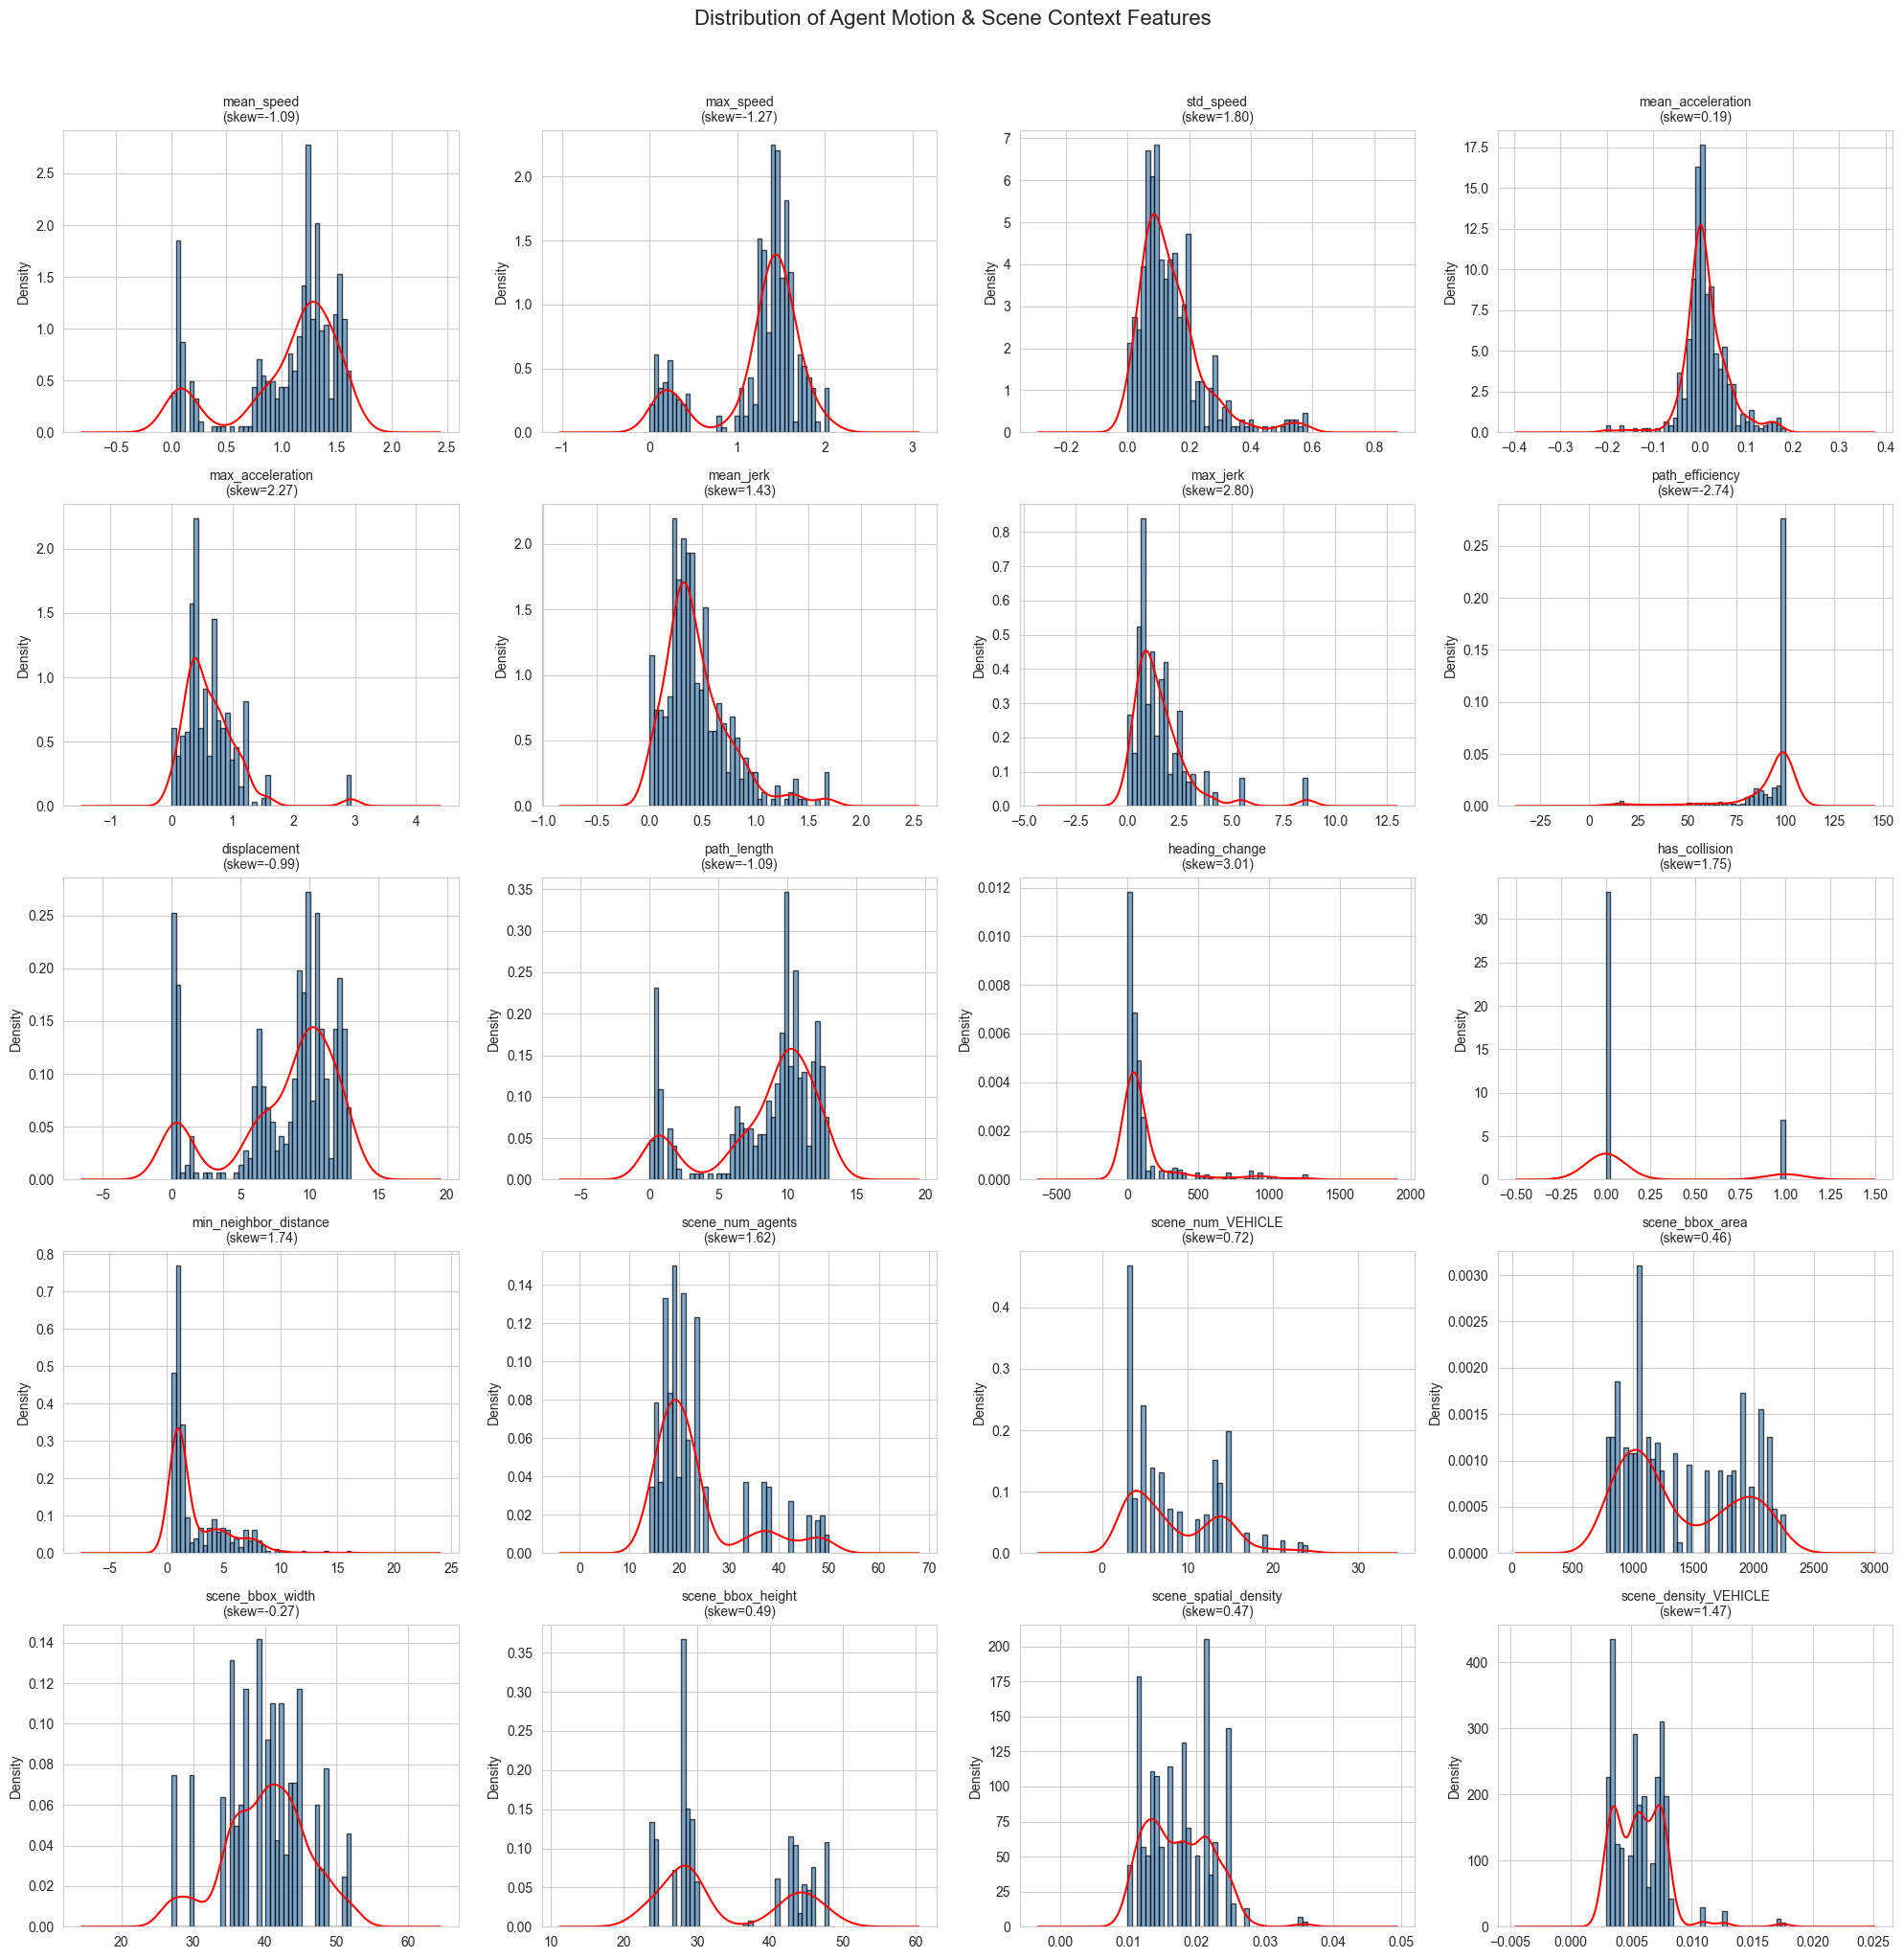

In [16]:
# Distribution of all numerical features
n_features = len(numerical_cols)
n_cols_plot = 4
n_rows_plot = int(np.ceil(n_features / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten() if n_features > 1 else [axes]

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=40, density=True, alpha=0.7, color="steelblue", edgecolor="black")
    df[col].dropna().plot.kde(ax=axes[i], color="red", linewidth=1.5)
    col_skew = skew(df[col].dropna())
    axes[i].set_title(f"{col}\n(skew={col_skew:.2f})", fontsize=10)
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Agent Motion & Scene Context Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Skewness summary table for all features and the target
skewness_df = pd.DataFrame({
    "Feature": numerical_cols + [target_col],
    "Skewness": [skew(df[c].dropna()) for c in numerical_cols + [target_col]],
    "Kurtosis": [stats.kurtosis(df[c].dropna()) for c in numerical_cols + [target_col]]
})
skewness_df["Skew Category"] = skewness_df["Skewness"].apply(
    lambda x: "Right-skewed" if x > 1 else ("Moderate" if x > 0.5 else ("Left-skewed" if x < -1 else "Symmetric"))
)
skewness_df = skewness_df.sort_values("Skewness", ascending=False).reset_index(drop=True)
print("Skewness Summary:")
skewness_df

Skewness Summary:


,Feature,Skewness,Kurtosis,Skew Category
0,heading_change,3.013466,8.802533,Right-skewed
1,max_jerk,2.798622,10.532398,Right-skewed
2,max_acceleration,2.272278,8.602435,Right-skewed
3,std_speed,1.803465,4.263631,Right-skewed
4,has_collision,1.750150,1.063025,Right-skewed
5,min_neighbor_distance,1.737306,3.199607,Right-skewed
6,scene_num_agents,1.619830,1.586252,Right-skewed
7,scene_density_VEHICLE,1.467618,5.765297,Right-skewed
8,ml_ade,1.460047,3.114523,Right-skewed
9,mean_jerk,1.429759,2.699040,Right-skewed


## 4. Correlation Analysis (Linear and Non-Linear)

Compute Pearson (linear) and Spearman (non-linear monotonic) correlations between agent motion features, scene context features, and the prediction error target. Mutual information scores detect arbitrary non-linear dependencies.

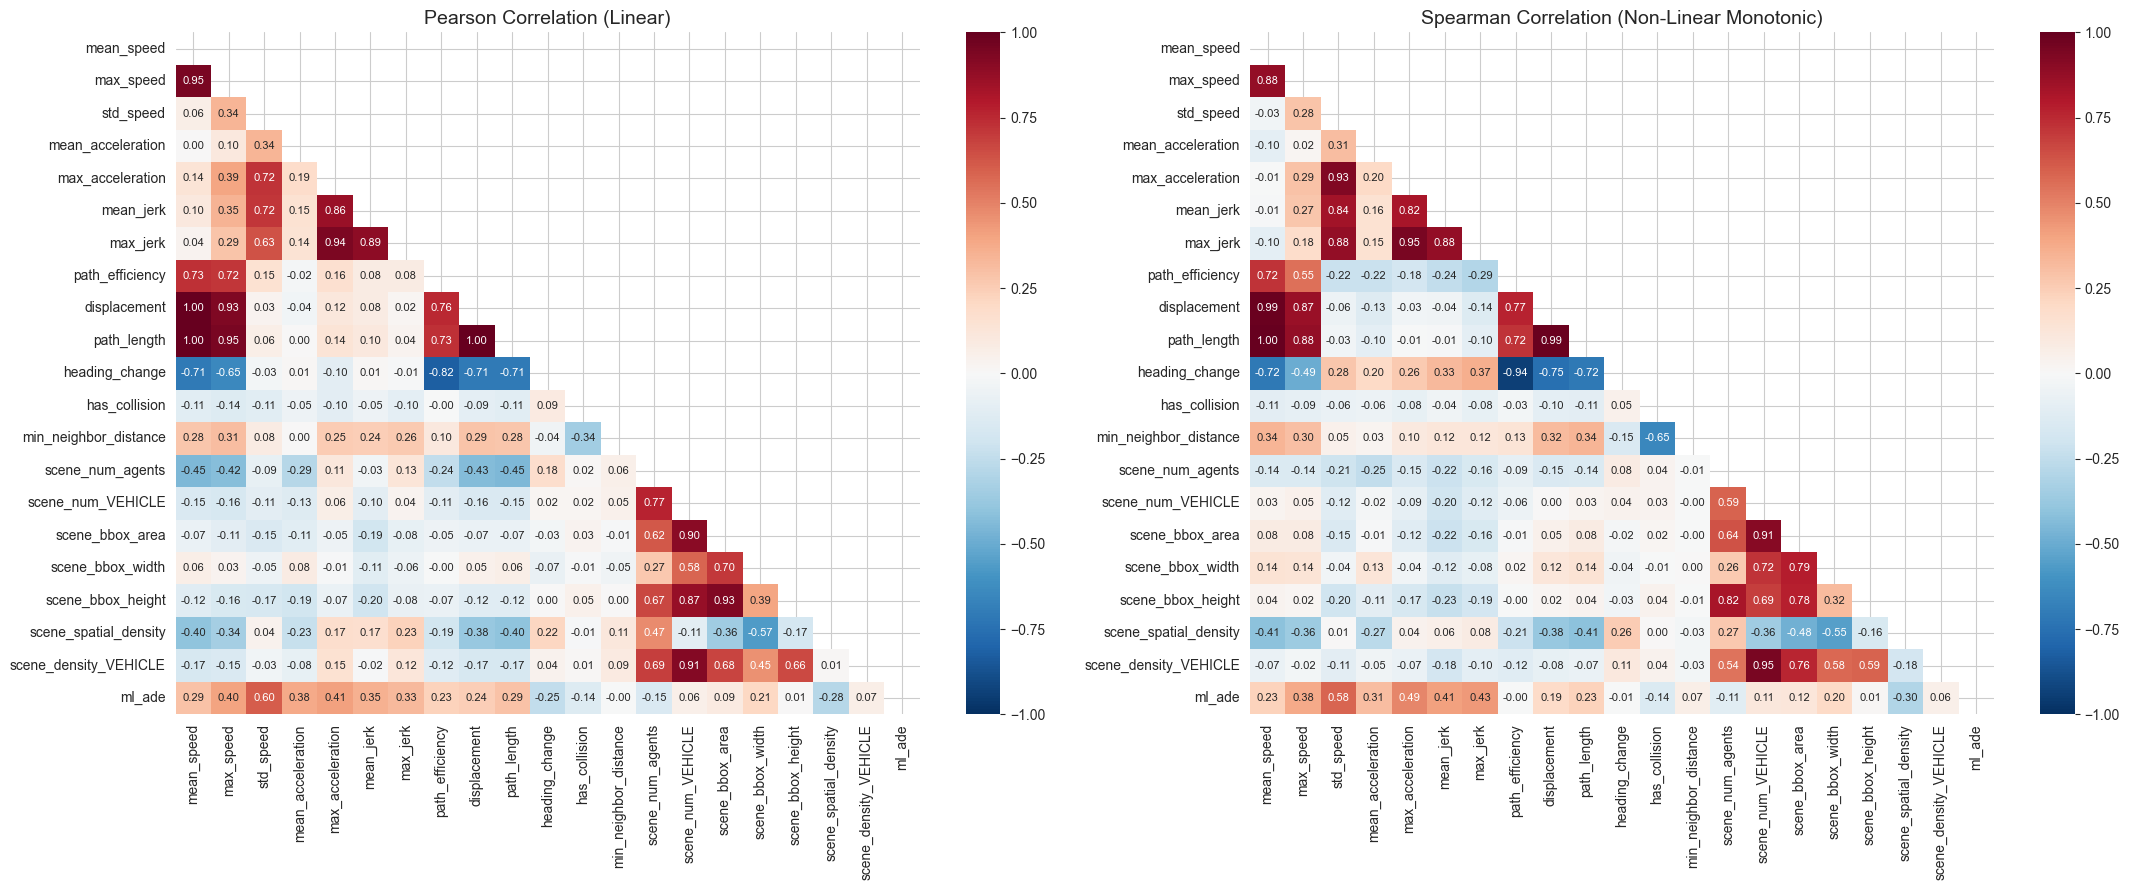

In [18]:
# Pearson and Spearman correlation matrices
all_numeric = numerical_cols + [target_col]
pearson_corr = df[all_numeric].corr(method="pearson")
spearman_corr = df[all_numeric].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Pearson heatmap
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[0], annot_kws={"size": 8})
axes[0].set_title("Pearson Correlation (Linear)", fontsize=14)

# Spearman heatmap
mask2 = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask2, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Spearman Correlation (Non-Linear Monotonic)", fontsize=14)

plt.tight_layout()
plt.savefig(SAVE_DIR / "correlation_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# Compare Pearson vs Spearman correlations with the target
corr_comparison = pd.DataFrame({
    "Feature": numerical_cols,
    "Pearson (with target)": [pearson_corr.loc[c, target_col] for c in numerical_cols],
    "Spearman (with target)": [spearman_corr.loc[c, target_col] for c in numerical_cols],
})
corr_comparison["Difference (|P - S|)"] = abs(
    corr_comparison["Pearson (with target)"] - corr_comparison["Spearman (with target)"]
)
corr_comparison = corr_comparison.sort_values("Pearson (with target)", ascending=False, key=abs).reset_index(drop=True)

print("Pearson vs Spearman Correlation with Target:")
print("(Large differences suggest non-linear relationships)")
corr_comparison

Pearson vs Spearman Correlation with Target:
(Large differences suggest non-linear relationships)


,Feature,Pearson (with target),Spearman (with target),Difference (|P - S|)
0,std_speed,0.604552,0.578428,0.026124
1,max_acceleration,0.408524,0.492077,0.083553
2,max_speed,0.404844,0.377828,0.027016
3,mean_acceleration,0.379868,0.305757,0.074111
4,mean_jerk,0.352247,0.409452,0.057205
5,max_jerk,0.326687,0.433106,0.106419
6,mean_speed,0.292345,0.232928,0.059417
7,path_length,0.292345,0.232929,0.059416
8,scene_spatial_density,-0.284785,-0.302386,0.017601
9,heading_change,-0.246151,-0.005637,0.240514


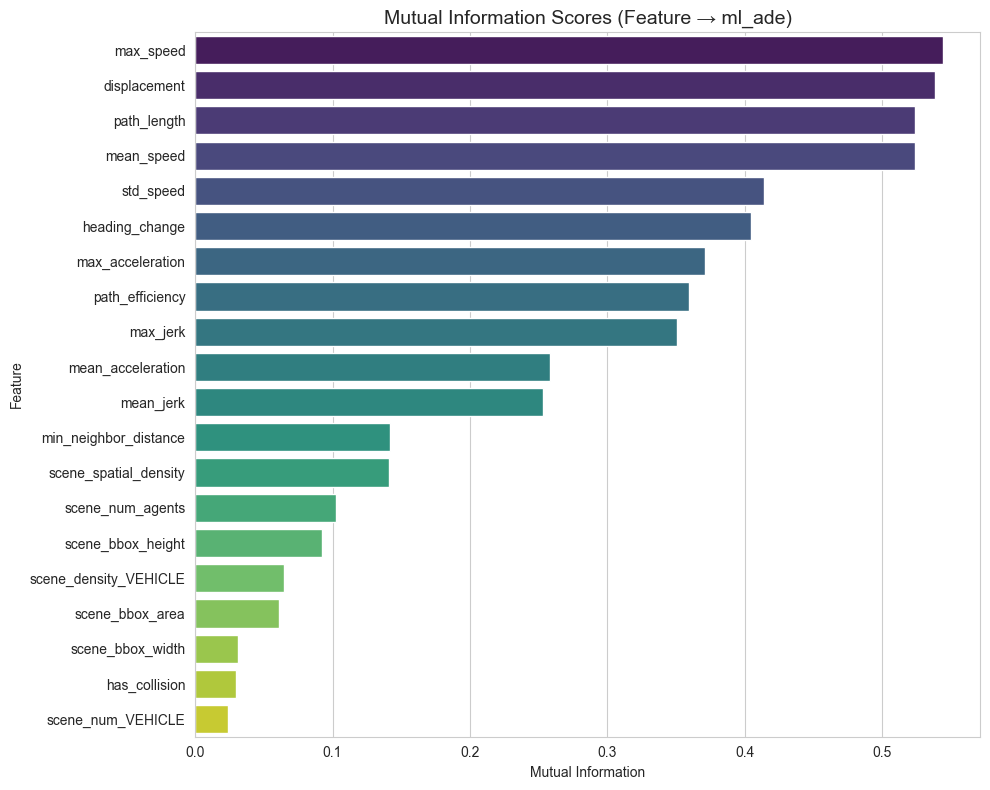

,Feature,Mutual Information
0,max_speed,0.544170
1,displacement,0.538797
2,path_length,0.524372
3,mean_speed,0.524242
4,std_speed,0.413781
5,heading_change,0.405001
6,max_acceleration,0.371108
7,path_efficiency,0.359630
8,max_jerk,0.350978
9,mean_acceleration,0.258314


In [20]:
# Mutual Information scores (detects non-linear dependencies)
X_for_mi = df[numerical_cols].dropna()
y_for_mi = df.loc[X_for_mi.index, target_col]

mi_scores = mutual_info_regression(X_for_mi, y_for_mi, random_state=42)
mi_df = pd.DataFrame({
    "Feature": numerical_cols,
    "Mutual Information": mi_scores
}).sort_values("Mutual Information", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(numerical_cols) * 0.4)))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis", ax=ax)
ax.set_title(f"Mutual Information Scores (Feature → {target_col})", fontsize=14)
plt.tight_layout()
plt.savefig(SAVE_DIR / "mutual_information_scores.png", dpi=150, bbox_inches="tight")
plt.show()

mi_df

## 5. Remove Highly Correlated Features

Identify pairs of features with absolute correlation above a threshold (e.g., 0.85). Remove one feature from each pair, keeping the one more correlated with the prediction error target.

In [21]:
def remove_highly_correlated(df, feature_cols, target_col, threshold=0.85):
    """
    Remove one feature from each pair of highly correlated features,
    keeping the one with higher absolute correlation with the target.
    
    Returns:
        selected_features: list of features to keep
        removed_features: list of removed features with reasons
    """
    corr_matrix = df[feature_cols].corr(method="pearson").abs()
    target_corr = df[feature_cols].corrwith(df[target_col]).abs()
    
    removed = set()
    removal_log = []
    
    for i in range(len(feature_cols)):
        for j in range(i + 1, len(feature_cols)):
            feat_i = feature_cols[i]
            feat_j = feature_cols[j]
            
            if feat_i in removed or feat_j in removed:
                continue
                
            if corr_matrix.loc[feat_i, feat_j] >= threshold:
                if target_corr[feat_i] >= target_corr[feat_j]:
                    removed.add(feat_j)
                    removal_log.append({
                        "Removed": feat_j,
                        "Kept": feat_i,
                        "Inter-correlation": corr_matrix.loc[feat_i, feat_j],
                        f"Corr with {target_col} (removed)": target_corr[feat_j],
                        f"Corr with {target_col} (kept)": target_corr[feat_i],
                    })
                else:
                    removed.add(feat_i)
                    removal_log.append({
                        "Removed": feat_i,
                        "Kept": feat_j,
                        "Inter-correlation": corr_matrix.loc[feat_i, feat_j],
                        f"Corr with {target_col} (removed)": target_corr[feat_i],
                        f"Corr with {target_col} (kept)": target_corr[feat_j],
                    })
    
    selected_features = [f for f in feature_cols if f not in removed]
    return selected_features, removal_log


# Apply correlation-based feature removal
CORR_THRESHOLD = 0.85
selected_features, removal_log = remove_highly_correlated(
    df, numerical_cols, target_col, threshold=CORR_THRESHOLD
)

print(f"Correlation threshold: {CORR_THRESHOLD}")
print(f"Original features: {len(numerical_cols)}")
print(f"Features after removal: {len(selected_features)}")
print(f"Features removed: {len(numerical_cols) - len(selected_features)}")

if removal_log:
    print(f"\nRemoval details:")
    removal_df = pd.DataFrame(removal_log)
    display(removal_df)
else:
    print("\nNo features exceeded the correlation threshold.")

print(f"\nSelected features: {selected_features}")

Correlation threshold: 0.85
Original features: 20
Features after removal: 13
Features removed: 7

Removal details:


,Removed,Kept,Inter-correlation,Corr with ml_ade (removed),Corr with ml_ade (kept)
0,mean_speed,max_speed,0.945788,0.292345,0.404844
1,displacement,max_speed,0.933267,0.243689,0.404844
2,path_length,max_speed,0.945788,0.292345,0.404844
3,mean_jerk,max_acceleration,0.860155,0.352247,0.408524
4,max_jerk,max_acceleration,0.944557,0.326687,0.408524
5,scene_num_VEHICLE,scene_bbox_area,0.903792,0.058121,0.088921
6,scene_bbox_height,scene_bbox_area,0.926792,0.006823,0.088921



Selected features: ['max_speed', 'std_speed', 'mean_acceleration', 'max_acceleration', 'path_efficiency', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_spatial_density', 'scene_density_VEHICLE']


## 6. Log Transform Target (If Right Skewed)

Trajectory prediction errors (ADE/FDE) are typically right-skewed. Apply `np.log1p()` transformation if skewness > 1. Compare distributions before and after.

Target skewness: 1.4600
Apply log transformation: True


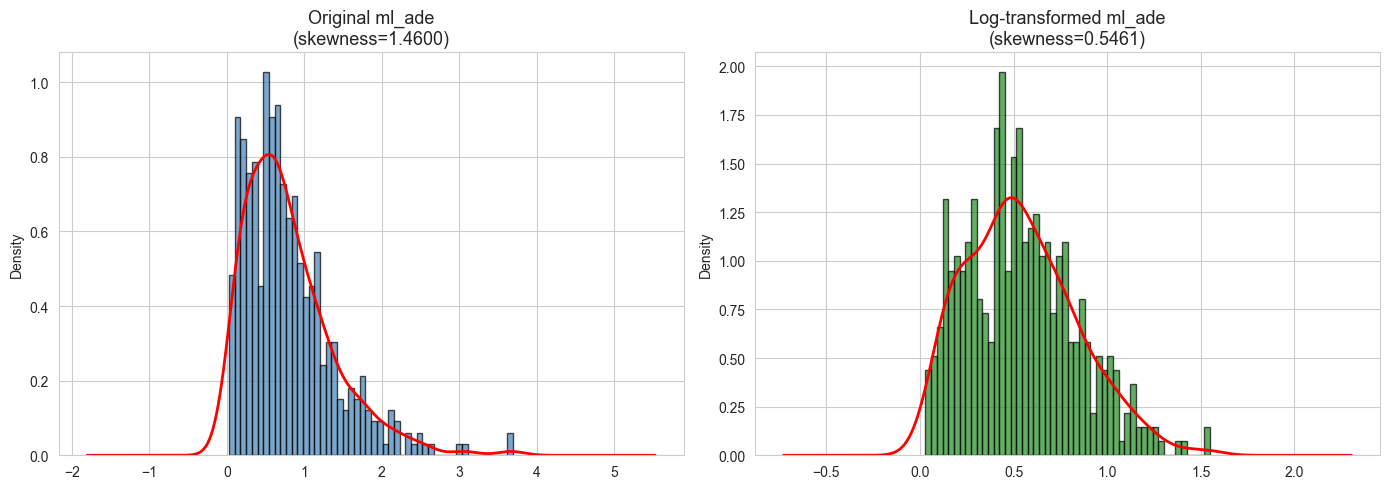


Log-transformed target column: 'ml_ade_log'


In [22]:
# Decide on log transformation
LOG_TRANSFORM = target_skewness > 1.0
print(f"Target skewness: {target_skewness:.4f}")
print(f"Apply log transformation: {LOG_TRANSFORM}")

if LOG_TRANSFORM:
    y_original = df[target_col].copy()
    # Use log1p for numerical stability (handles values near zero)
    df[f"{target_col}_log"] = np.log1p(df[target_col])
    y_transformed_col = f"{target_col}_log"
    
    # Plot before and after
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(y_original.dropna(), bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="black")
    y_original.dropna().plot.kde(ax=axes[0], color="red", linewidth=2)
    axes[0].set_title(f"Original {target_col}\n(skewness={skew(y_original.dropna()):.4f})", fontsize=13)
    
    y_log = df[y_transformed_col]
    axes[1].hist(y_log.dropna(), bins=50, density=True, alpha=0.7, color="forestgreen", edgecolor="black")
    y_log.dropna().plot.kde(ax=axes[1], color="red", linewidth=2)
    axes[1].set_title(f"Log-transformed {target_col}\n(skewness={skew(y_log.dropna()):.4f})", fontsize=13)
    
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"target_log_transform_{target_col}.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"\nLog-transformed target column: '{y_transformed_col}'")
else:
    y_transformed_col = target_col
    print("No transformation applied — target is approximately symmetric.")

## 7. Standardize Features

Apply `StandardScaler` to standardize all selected features to zero mean and unit variance. This is important for GAM spline fitting stability.

In [23]:
# Prepare the data (drop rows with NaN in selected features or target)
model_df = df[selected_features + [y_transformed_col]].dropna().copy()
print(f"Rows available for modeling: {len(model_df)} (dropped {len(df) - len(model_df)} rows with NaN)")

X = model_df[selected_features].values
y = model_df[y_transformed_col].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Rows available for modeling: 451 (dropped 0 rows with NaN)

Feature matrix shape: (451, 13)
Target vector shape: (451,)


## 8. Train/Test Split

Split data into 80% training and 20% test sets. Standardization is fitted on training data only to prevent data leakage.

In [24]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify standardization
train_stats = pd.DataFrame({
    "Feature": selected_features,
    "Train Mean (scaled)": X_train_scaled.mean(axis=0),
    "Train Std (scaled)": X_train_scaled.std(axis=0),
    "Test Mean (scaled)": X_test_scaled.mean(axis=0),
    "Test Std (scaled)": X_test_scaled.std(axis=0),
})
print("\nStandardization verification:")
train_stats

Training set: 360 samples
Test set:     91 samples

Standardization verification:


,Feature,Train Mean (scaled),Train Std (scaled),Test Mean (scaled),Test Std (scaled)
0,max_speed,-4.938257e-15,1.0,-0.183278,1.119693
1,std_speed,-6.914222e-16,1.0,-0.204614,0.721506
2,mean_acceleration,2.288293e-16,1.0,-0.119929,0.787082
3,max_acceleration,1.765043e-15,1.0,-0.120781,1.001334
4,path_efficiency,9.959626e-16,1.0,-0.176014,1.355688
5,heading_change,1.409366e-16,1.0,0.003862,1.002139
6,has_collision,2.837237e-17,1.0,-0.019565,0.982674
7,min_neighbor_distance,-3.935124e-16,1.0,-0.075445,0.854004
8,scene_num_agents,1.011537e-16,1.0,0.198966,1.073346
9,scene_bbox_area,1.550611e-15,1.0,0.196319,1.026170


## 9. Fit Linear GAM

Fit a `LinearGAM` using spline terms `s()` for all continuous features. Use grid search over lambda values for regularization tuning.

In [25]:
# Build GAM terms: spline term s() for each feature
n_features_gam = X_train_scaled.shape[1]
gam_terms = s(0)
for i in range(1, n_features_gam):
    gam_terms += s(i)

# Fit LinearGAM with grid search for lambda
linear_gam = LinearGAM(gam_terms)
linear_gam.gridsearch(
    X_train_scaled, y_train,
    lam=np.logspace(-3, 3, 11),
    progress=False
)

print("LinearGAM Summary:")
print("=" * 60)
linear_gam.summary()

LinearGAM Summary:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     27.8269
Link Function:                     IdentityLink Log Likelihood:                                   107.3093
Number of Samples:                          360 AIC:                                             -156.9648
                                                AICc:                                            -151.7565
                                                GCV:                                                0.0404
                                                Scale:                                              0.1867
                                                Pseudo R-Squared:                                   0.6278
Feature Function  

## 10. Evaluate Model Performance (R², MAE, RMSE)

Generate predictions on train and test sets. If the target was log-transformed, apply inverse transformation before computing metrics on the original scale (meters for ADE/FDE).

In [26]:
def evaluate_gam_model(model, X_train, y_train, X_test, y_test, log_transformed=False, model_name="Model"):
    """Evaluate a GAM model and return metrics on original scale."""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    if log_transformed:
        # Inverse transform predictions and actuals for original-scale metrics
        y_train_orig = np.expm1(y_train)
        y_test_orig = np.expm1(y_test)
        y_train_pred_orig = np.expm1(y_train_pred)
        y_test_pred_orig = np.expm1(y_test_pred)
    else:
        y_train_orig = y_train
        y_test_orig = y_test
        y_train_pred_orig = y_train_pred
        y_test_pred_orig = y_test_pred
    
    metrics = {
        "Model": model_name,
        "R² (Train)": r2_score(y_train_orig, y_train_pred_orig),
        "R² (Test)": r2_score(y_test_orig, y_test_pred_orig),
        "MAE (Train)": mean_absolute_error(y_train_orig, y_train_pred_orig),
        "MAE (Test)": mean_absolute_error(y_test_orig, y_test_pred_orig),
        "RMSE (Train)": np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig)),
        "RMSE (Test)": np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig)),
    }
    
    return metrics, y_test_orig, y_test_pred_orig


# Evaluate LinearGAM
linear_metrics, y_test_orig, y_test_pred_linear = evaluate_gam_model(
    linear_gam, X_train_scaled, y_train, X_test_scaled, y_test,
    log_transformed=LOG_TRANSFORM, model_name="LinearGAM"
)

results_list = [linear_metrics]
results_df = pd.DataFrame(results_list)
print("LinearGAM Performance:")
results_df

LinearGAM Performance:


,Model,R² (Train),R² (Test),MAE (Train),MAE (Test),RMSE (Train),RMSE (Test)
0,LinearGAM,0.610975,0.619648,0.264474,0.252541,0.366365,0.344889


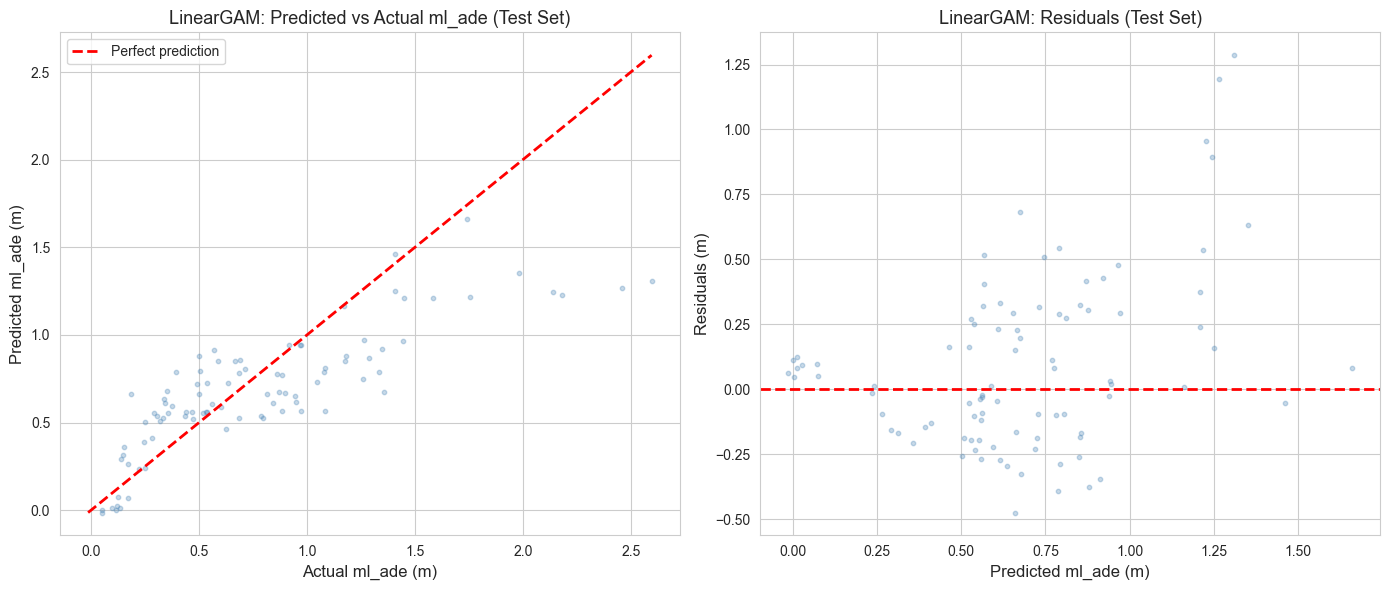

In [27]:
# Predicted vs Actual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Test set: Predicted vs Actual
axes[0].scatter(y_test_orig, y_test_pred_linear, alpha=0.3, s=10, color="steelblue")
lims = [
    min(y_test_orig.min(), y_test_pred_linear.min()),
    max(y_test_orig.max(), y_test_pred_linear.max())
]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel(f"Actual {target_col} (m)", fontsize=12)
axes[0].set_ylabel(f"Predicted {target_col} (m)", fontsize=12)
axes[0].set_title(f"LinearGAM: Predicted vs Actual {target_col} (Test Set)", fontsize=13)
axes[0].legend()

# Residuals
residuals = y_test_orig - y_test_pred_linear
axes[1].scatter(y_test_pred_linear, residuals, alpha=0.3, s=10, color="steelblue")
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel(f"Predicted {target_col} (m)", fontsize=12)
axes[1].set_ylabel("Residuals (m)", fontsize=12)
axes[1].set_title("LinearGAM: Residuals (Test Set)", fontsize=13)

plt.tight_layout()
plt.savefig(SAVE_DIR / f"linear_gam_predictions_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Try Alternative GAM Setups (e.g., GammaGAM)

Fit alternative GAM models. `GammaGAM` is suitable for positive, right-skewed targets (like ADE/FDE) without requiring a log transformation.

In [28]:
# For GammaGAM, we need the original (non-log-transformed) positive target
if LOG_TRANSFORM:
    y_train_original = np.expm1(y_train)
    y_test_original = np.expm1(y_test)
else:
    y_train_original = y_train.copy()
    y_test_original = y_test.copy()

# Ensure all target values are positive (GammaGAM requirement)
positive_mask_train = y_train_original > 0
positive_mask_test = y_test_original > 0

if positive_mask_train.all() and positive_mask_test.all():
    # Build GammaGAM terms
    gamma_terms = s(0)
    for i in range(1, n_features_gam):
        gamma_terms += s(i)
    
    gamma_gam = GammaGAM(gamma_terms)
    gamma_gam.gridsearch(
        X_train_scaled[positive_mask_train], y_train_original[positive_mask_train],
        lam=np.logspace(-3, 3, 11),
        progress=False
    )
    
    print("GammaGAM Summary:")
    print("=" * 60)
    gamma_gam.summary()
    
    # Evaluate GammaGAM (predictions are already on original scale)
    y_test_pred_gamma = gamma_gam.predict(X_test_scaled[positive_mask_test])
    
    gamma_metrics = {
        "Model": "GammaGAM",
        "R² (Train)": r2_score(
            y_train_original[positive_mask_train],
            gamma_gam.predict(X_train_scaled[positive_mask_train])
        ),
        "R² (Test)": r2_score(y_test_original[positive_mask_test], y_test_pred_gamma),
        "MAE (Train)": mean_absolute_error(
            y_train_original[positive_mask_train],
            gamma_gam.predict(X_train_scaled[positive_mask_train])
        ),
        "MAE (Test)": mean_absolute_error(y_test_original[positive_mask_test], y_test_pred_gamma),
        "RMSE (Train)": np.sqrt(mean_squared_error(
            y_train_original[positive_mask_train],
            gamma_gam.predict(X_train_scaled[positive_mask_train])
        )),
        "RMSE (Test)": np.sqrt(mean_squared_error(y_test_original[positive_mask_test], y_test_pred_gamma)),
    }
    results_list.append(gamma_metrics)
else:
    print("WARNING: Target contains non-positive values (zero ADE/FDE). GammaGAM requires strictly positive targets.")
    print(f"  Non-positive in train: {(~positive_mask_train).sum()}")
    print(f"  Non-positive in test: {(~positive_mask_test).sum()}")
    print("Skipping GammaGAM fitting.")

GammaGAM Summary:
GammaGAM                                                                                                  
=============================================== ==========================================================
Distribution:                         GammaDist Effective DoF:                                     27.8269
Link Function:                          LogLink Log Likelihood:                                   -94.2011
Number of Samples:                          360 AIC:                                              246.0561
                                                AICc:                                             251.2644
                                                GCV:                                                0.2502
                                                Scale:                                              0.4462
                                                Pseudo R-Squared:                                   0.6583
Feature Function   

In [29]:
# Also try LinearGAM on original (non-transformed) target for comparison
linear_gam_orig = LinearGAM(gam_terms)
linear_gam_orig.gridsearch(
    X_train_scaled, y_train_original,
    lam=np.logspace(-3, 3, 11),
    progress=False
)

linear_orig_metrics, _, _ = evaluate_gam_model(
    linear_gam_orig, X_train_scaled, y_train_original, X_test_scaled, y_test_original,
    log_transformed=False, model_name="LinearGAM (no log)"
)
results_list.append(linear_orig_metrics)

# Comparison table
results_df = pd.DataFrame(results_list)
print("Model Comparison:")
results_df

Model Comparison:


,Model,R² (Train),R² (Test),MAE (Train),MAE (Test),RMSE (Train),RMSE (Test)
0,LinearGAM,0.610975,0.619648,0.264474,0.252541,0.366365,0.344889
1,GammaGAM,0.608612,0.658978,0.266244,0.240059,0.367476,0.326571
2,LinearGAM (no log),0.606772,0.637393,0.276078,0.259973,0.368339,0.336747


## 12. Identify and Remove Non-Significant Features

Examine p-values from the best GAM model. Identify features with p-values above a significance threshold (e.g., 0.05). Visualize partial dependence plots to understand each feature's effect on prediction error.

In [30]:
# Determine the best model based on test R²
best_model_name = results_df.loc[results_df["R² (Test)"].idxmax(), "Model"]
print(f"Best model by Test R²: {best_model_name}")

# Use the LinearGAM (log-transformed if applicable) for feature significance analysis
best_gam = linear_gam

# Extract p-values from the model
print(f"\nFeature significance analysis (from LinearGAM):")
print("=" * 60)

significance_data = []
for i, feature in enumerate(selected_features):
    p_value = linear_gam.statistics_["p_values"][i]
    significance_data.append({
        "Feature Index": i,
        "Feature": feature,
        "p-value": p_value,
        "Significant (p < 0.05)": "✓" if p_value < 0.05 else "✗"
    })

significance_df = pd.DataFrame(significance_data).sort_values("p-value").reset_index(drop=True)
print(significance_df.to_string(index=False))

Best model by Test R²: GammaGAM

Feature significance analysis (from LinearGAM):
 Feature Index               Feature      p-value Significant (p < 0.05)
             1             std_speed 5.039380e-11                      ✓
             0             max_speed 6.530532e-09                      ✓
             4       path_efficiency 9.040879e-05                      ✓
             5        heading_change 4.605989e-04                      ✓
             2     mean_acceleration 9.872389e-04                      ✓
             3      max_acceleration 2.565182e-03                      ✓
            10      scene_bbox_width 5.133472e-01                      ✗
            11 scene_spatial_density 5.369747e-01                      ✗
             7 min_neighbor_distance 6.353312e-01                      ✗
            12 scene_density_VEHICLE 6.651711e-01                      ✗
             9       scene_bbox_area 6.893267e-01                      ✗
             8      scene_num_agents 8.8369

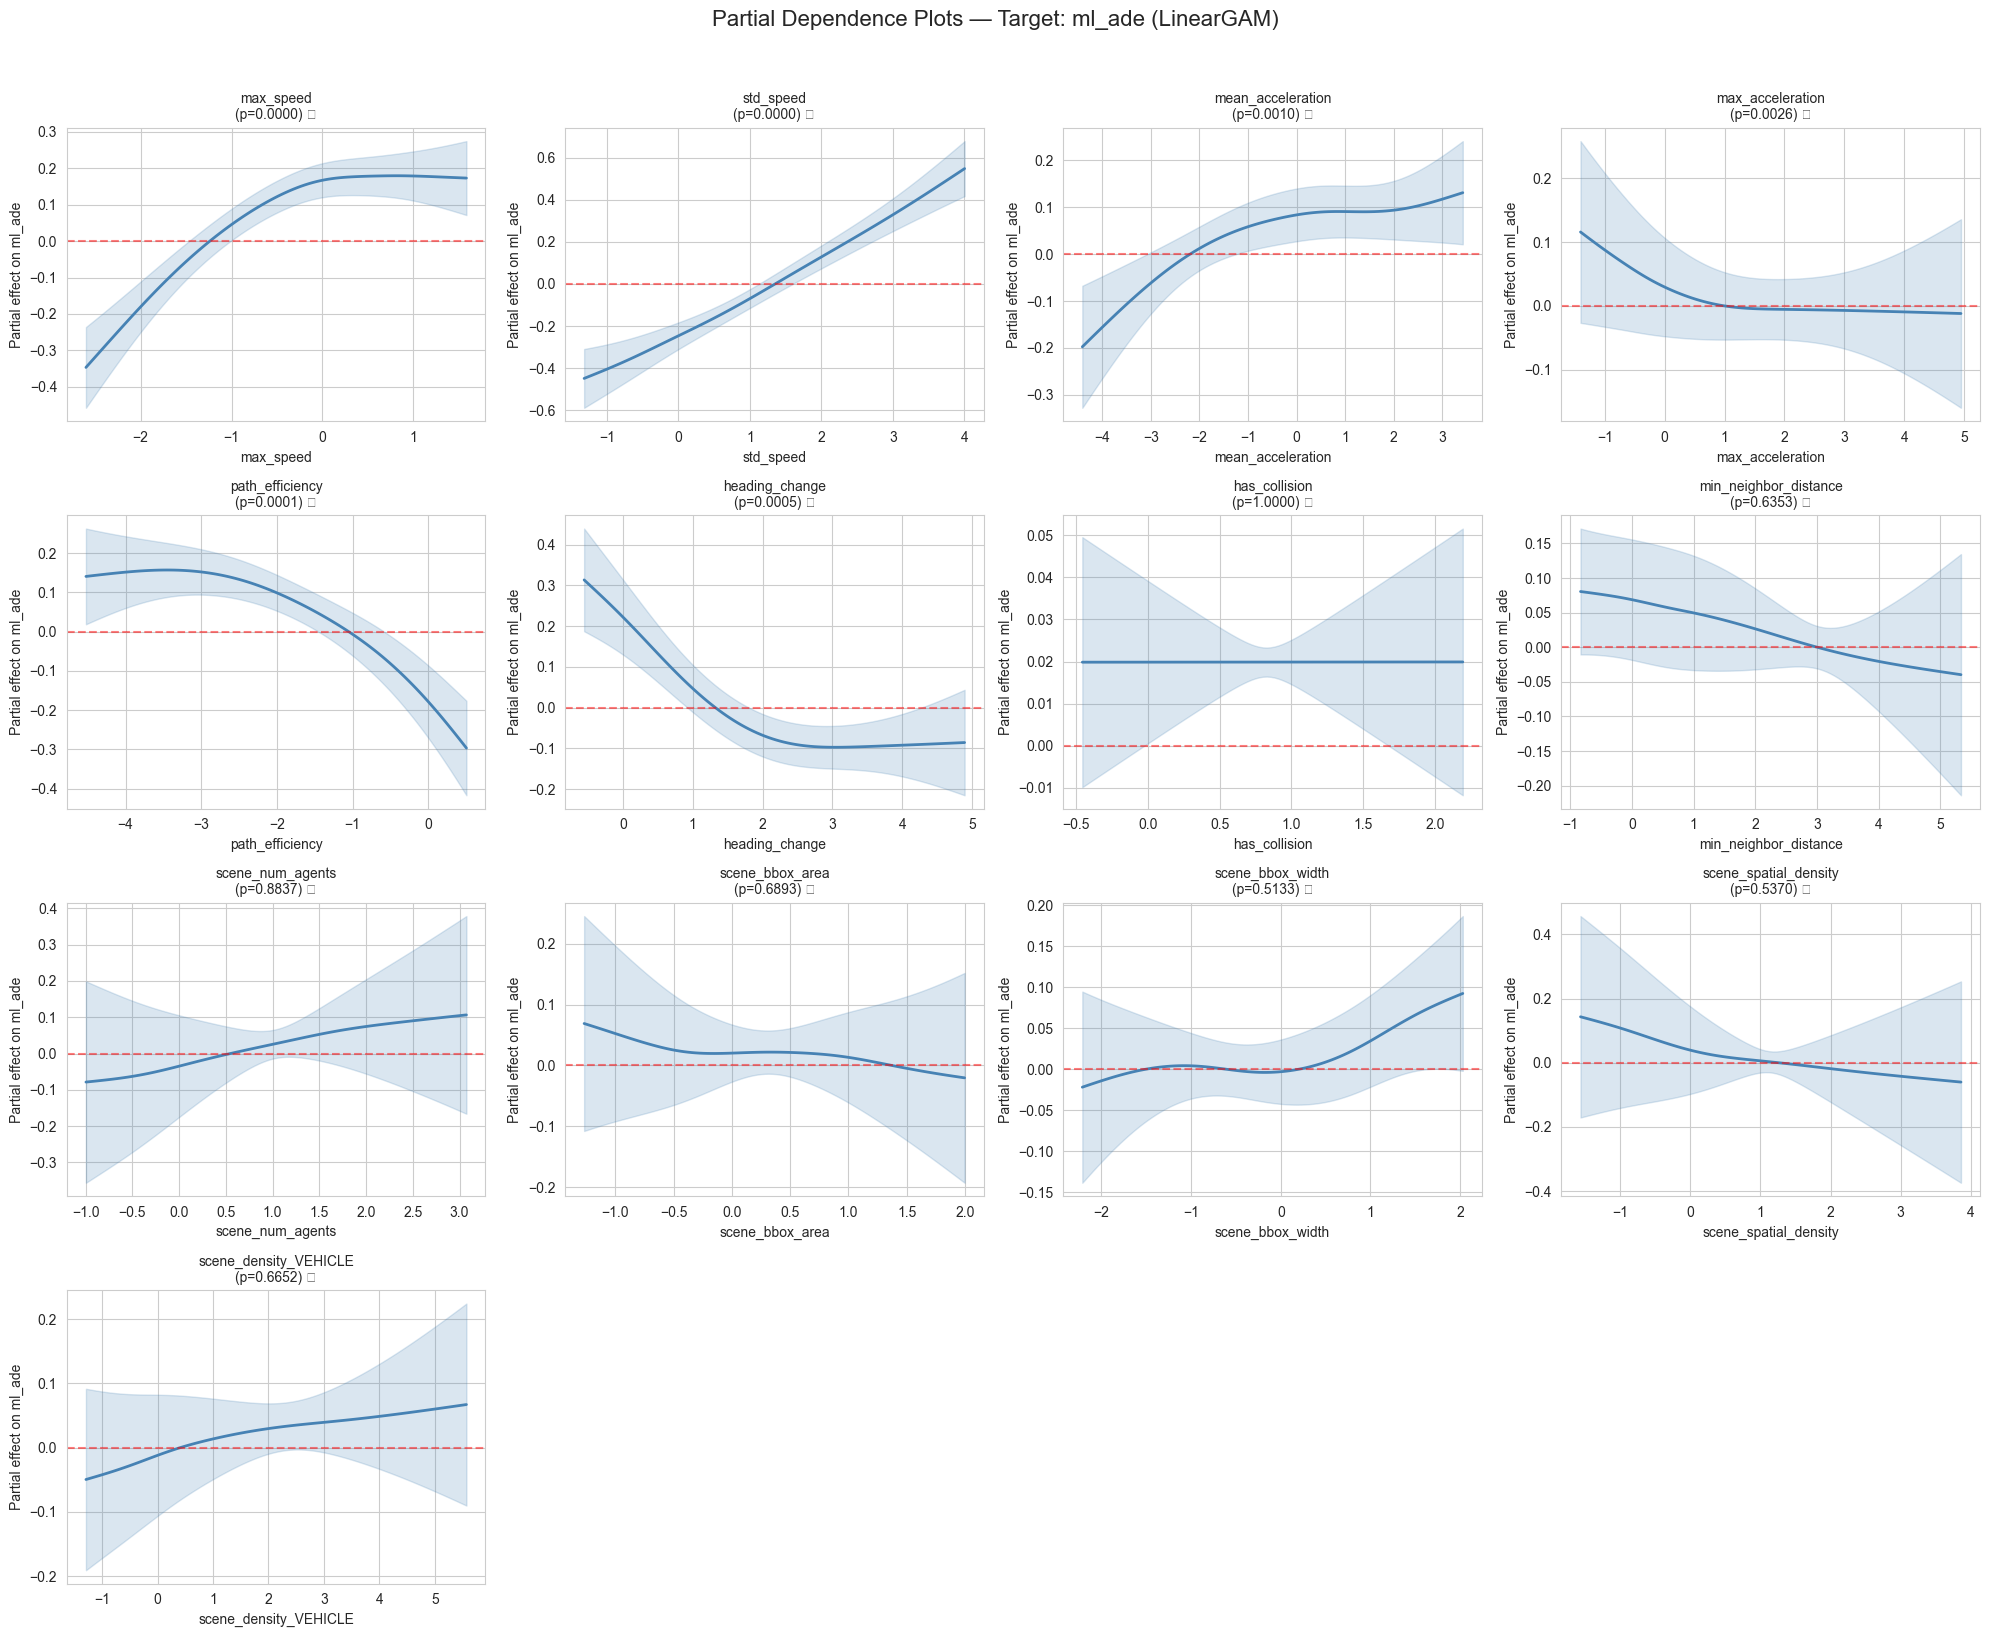

In [31]:
# Partial dependence plots for all features
n_cols_pdp = 4
n_rows_pdp = int(np.ceil(n_features_gam / n_cols_pdp))
fig, axes = plt.subplots(n_rows_pdp, n_cols_pdp, figsize=(5 * n_cols_pdp, 4 * n_rows_pdp))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    XX = linear_gam.generate_X_grid(term=i)
    pdep, confi = linear_gam.partial_dependence(term=i, X=XX, width=0.95)
    
    axes[i].plot(XX[:, i], pdep, color="steelblue", linewidth=2)
    axes[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="steelblue")
    p_val = significance_df[significance_df["Feature"] == feature]["p-value"].values[0]
    sig_marker = "✓" if p_val < 0.05 else "✗"
    axes[i].set_title(f"{feature}\n(p={p_val:.4f}) {sig_marker}", fontsize=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(f"Partial effect on {target_col}")
    axes[i].axhline(y=0, color="red", linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Partial Dependence Plots — Target: {target_col} (LinearGAM)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"partial_dependence_all_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

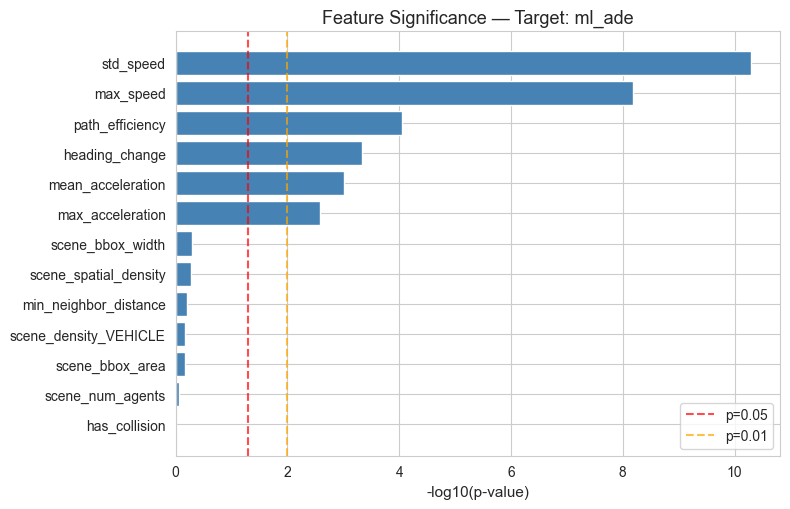

In [32]:
# Feature importance plot (-log10 p-value)
sig_sorted = significance_df.sort_values("p-value", ascending=False)
importance_vals = [-np.log10(max(p, 1e-300)) for p in sig_sorted["p-value"]]

fig, ax = plt.subplots(figsize=(8, max(4, len(selected_features) * 0.4)))
bars = ax.barh(sig_sorted["Feature"], importance_vals, color="steelblue")
ax.axvline(x=-np.log10(0.05), color="red", linestyle="--", label="p=0.05", alpha=0.7)
ax.axvline(x=-np.log10(0.01), color="orange", linestyle="--", label="p=0.01", alpha=0.7)
ax.set_xlabel("-log10(p-value)", fontsize=11)
ax.set_title(f"Feature Significance — Target: {target_col}", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / f"feature_significance_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# Identify and remove non-significant features
SIGNIFICANCE_THRESHOLD = 0.05
significant_mask = significance_df["p-value"] < SIGNIFICANCE_THRESHOLD
significant_features = significance_df.loc[significant_mask, "Feature"].tolist()
removed_features_sig = significance_df.loc[~significant_mask, "Feature"].tolist()

print(f"Significance threshold: {SIGNIFICANCE_THRESHOLD}")
print(f"Significant features ({len(significant_features)}): {significant_features}")
print(f"Non-significant features removed ({len(removed_features_sig)}): {removed_features_sig}")

Significance threshold: 0.05
Significant features (6): ['std_speed', 'max_speed', 'path_efficiency', 'heading_change', 'mean_acceleration', 'max_acceleration']
Non-significant features removed (7): ['scene_bbox_width', 'scene_spatial_density', 'min_neighbor_distance', 'scene_density_VEHICLE', 'scene_bbox_area', 'scene_num_agents', 'has_collision']


## 13. Refit GAM on Newly Selected Features

Refit the best GAM variant using only the significant features. Re-run grid search for optimal lambda.

In [34]:
# Get indices of significant features in the original selected_features list
sig_indices = [selected_features.index(f) for f in significant_features]

# Subset the training and test data
X_train_sig = X_train_scaled[:, sig_indices]
X_test_sig = X_test_scaled[:, sig_indices]

print(f"Reduced feature matrix: {X_train_sig.shape[1]} features (from {X_train_scaled.shape[1]})")

# Build new GAM terms for reduced features
reduced_terms = s(0)
for i in range(1, len(sig_indices)):
    reduced_terms += s(i)

# Refit LinearGAM
linear_gam_reduced = LinearGAM(reduced_terms)
linear_gam_reduced.gridsearch(
    X_train_sig, y_train,
    lam=np.logspace(-3, 3, 11),
    progress=False
)

print("\nReduced LinearGAM Summary:")
print("=" * 60)
linear_gam_reduced.summary()

Reduced feature matrix: 6 features (from 13)

Reduced LinearGAM Summary:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     35.8803
Link Function:                     IdentityLink Log Likelihood:                                    119.322
Number of Samples:                          360 AIC:                                             -164.8835
                                                AICc:                                            -156.2095
                                                GCV:                                                0.0405
                                                Scale:                                              0.1826
                                                Pseudo R-Squared:      

In [35]:
# Also try GammaGAM on reduced features if applicable
if positive_mask_train.all() and positive_mask_test.all():
    gamma_gam_reduced = GammaGAM(reduced_terms)
    gamma_gam_reduced.gridsearch(
        X_train_sig[positive_mask_train], y_train_original[positive_mask_train],
        lam=np.logspace(-3, 3, 11),
        progress=False
    )
    print("\nReduced GammaGAM Summary:")
    print("=" * 60)
    gamma_gam_reduced.summary()


Reduced GammaGAM Summary:
GammaGAM                                                                                                  
=============================================== ==========================================================
Distribution:                         GammaDist Effective DoF:                                      46.356
Link Function:                          LogLink Log Likelihood:                                    -72.493
Number of Samples:                          360 AIC:                                               239.698
                                                AICc:                                             254.3939
                                                GCV:                                                0.2493
                                                Scale:                                              0.4146
                                                Pseudo R-Squared:                                   0.7124
Feature Fu

## 14. Final Model Evaluation and Comparison

Evaluate the refitted models on test data. Create a comprehensive comparison table and diagnostic plots.

In [36]:
# Evaluate reduced LinearGAM
reduced_linear_metrics, y_test_orig_r, y_test_pred_reduced = evaluate_gam_model(
    linear_gam_reduced, X_train_sig, y_train, X_test_sig, y_test,
    log_transformed=LOG_TRANSFORM, model_name="LinearGAM (reduced)"
)
results_list.append(reduced_linear_metrics)

# Evaluate reduced GammaGAM if available
if positive_mask_train.all() and positive_mask_test.all():
    y_test_pred_gamma_red = gamma_gam_reduced.predict(X_test_sig[positive_mask_test])
    gamma_red_metrics = {
        "Model": "GammaGAM (reduced)",
        "R² (Train)": r2_score(
            y_train_original[positive_mask_train],
            gamma_gam_reduced.predict(X_train_sig[positive_mask_train])
        ),
        "R² (Test)": r2_score(y_test_original[positive_mask_test], y_test_pred_gamma_red),
        "MAE (Train)": mean_absolute_error(
            y_train_original[positive_mask_train],
            gamma_gam_reduced.predict(X_train_sig[positive_mask_train])
        ),
        "MAE (Test)": mean_absolute_error(y_test_original[positive_mask_test], y_test_pred_gamma_red),
        "RMSE (Train)": np.sqrt(mean_squared_error(
            y_train_original[positive_mask_train],
            gamma_gam_reduced.predict(X_train_sig[positive_mask_train])
        )),
        "RMSE (Test)": np.sqrt(mean_squared_error(y_test_original[positive_mask_test], y_test_pred_gamma_red)),
    }
    results_list.append(gamma_red_metrics)

# Final comparison table
final_results = pd.DataFrame(results_list)
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
final_results

FINAL MODEL COMPARISON


,Model,R² (Train),R² (Test),MAE (Train),MAE (Test),RMSE (Train),RMSE (Test)
0,LinearGAM,0.610975,0.619648,0.264474,0.252541,0.366365,0.344889
1,GammaGAM,0.608612,0.658978,0.266244,0.240059,0.367476,0.326571
2,LinearGAM (no log),0.606772,0.637393,0.276078,0.259973,0.368339,0.336747
3,LinearGAM (reduced),0.640603,0.586395,0.252845,0.266192,0.352138,0.359649
4,GammaGAM (reduced),0.664996,0.617765,0.243031,0.250207,0.339978,0.345741


Best Model: GammaGAM
  R² (Test):   0.6590
  MAE (Test):  0.2401 m
  RMSE (Test): 0.3266 m


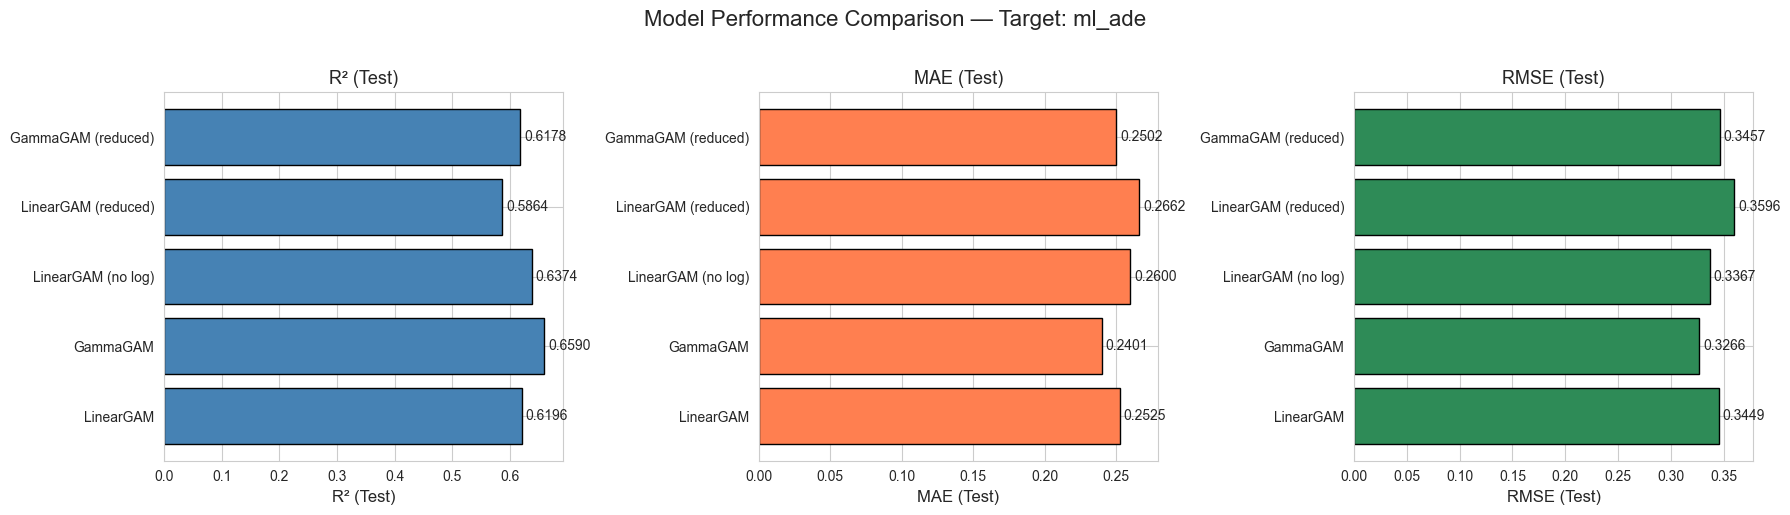

In [37]:
# Highlight the best model
best_idx = final_results["R² (Test)"].idxmax()
best_model_final = final_results.loc[best_idx]
print(f"Best Model: {best_model_final['Model']}")
print(f"  R² (Test):   {best_model_final['R² (Test)']:.4f}")
print(f"  MAE (Test):  {best_model_final['MAE (Test)']:.4f} m")
print(f"  RMSE (Test): {best_model_final['RMSE (Test)']:.4f} m")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ["R² (Test)", "MAE (Test)", "RMSE (Test)"]
colors = ["steelblue", "coral", "seagreen"]

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    bars = ax.barh(final_results["Model"], final_results[metric], color=color, edgecolor="black")
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=13)
    for bar, val in zip(bars, final_results[metric]):
        ax.text(bar.get_width() + 0.01 * abs(final_results[metric].max()), 
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=10)

plt.suptitle(f"Model Performance Comparison — Target: {target_col}", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"model_comparison_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

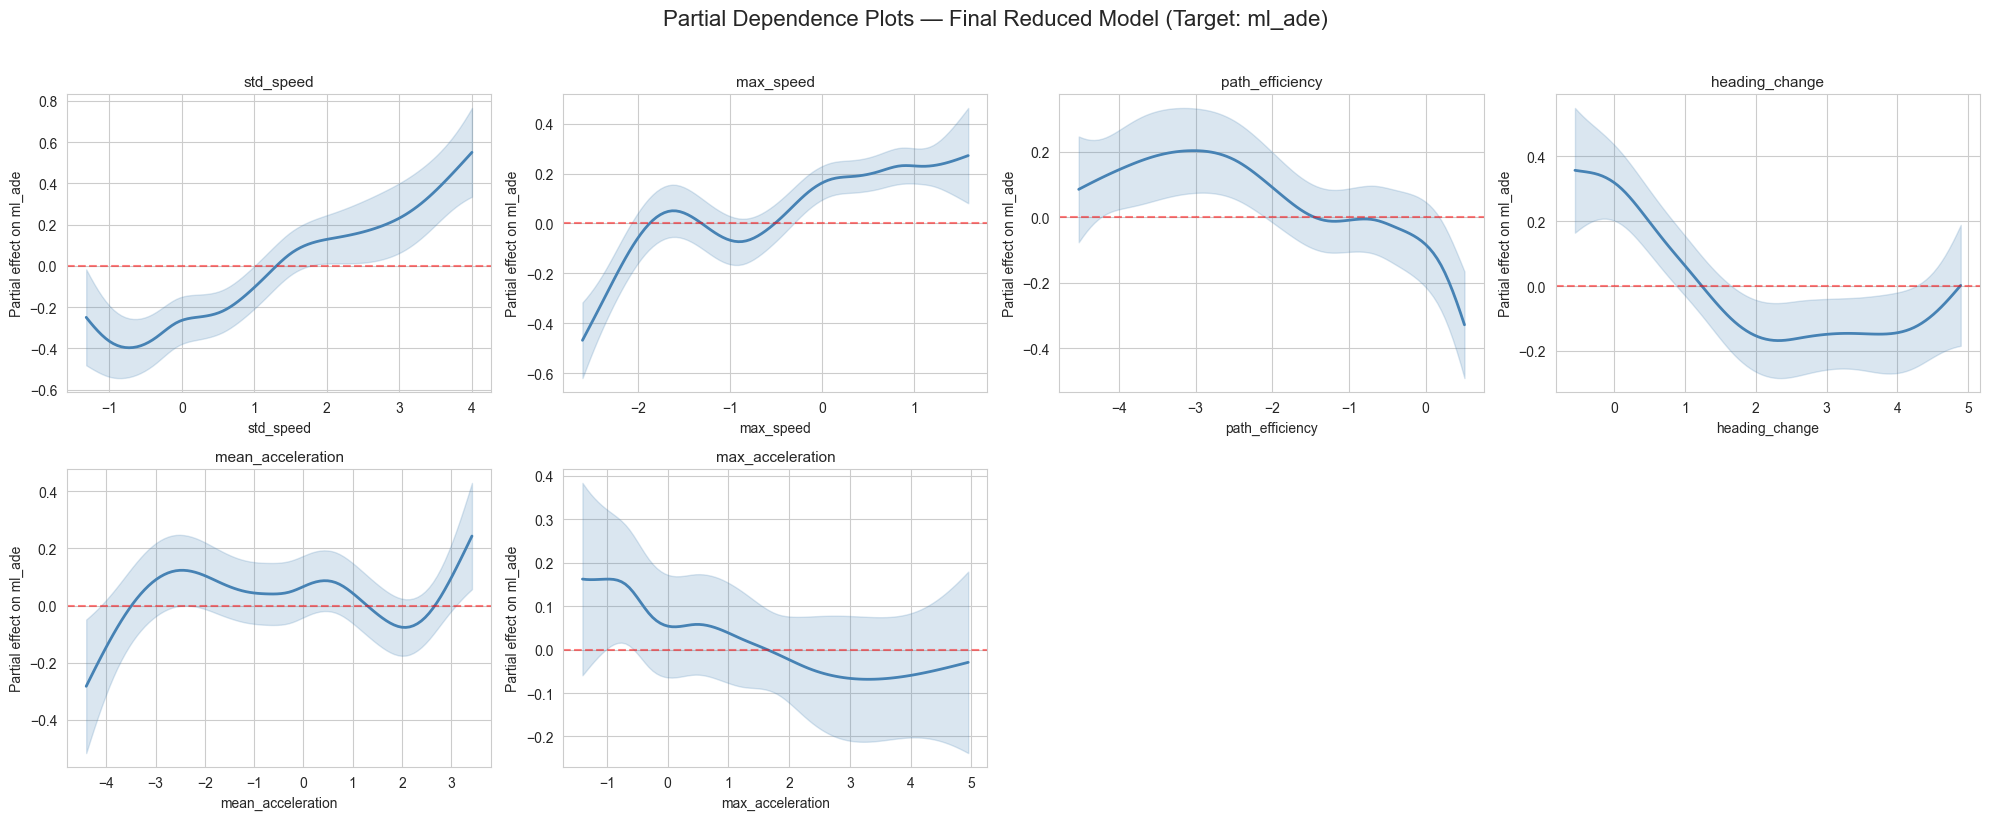

In [38]:
# Partial dependence plots for the final reduced model
n_sig = len(significant_features)
n_cols_final = min(4, n_sig)
n_rows_final = int(np.ceil(n_sig / n_cols_final))
fig, axes = plt.subplots(n_rows_final, n_cols_final, figsize=(5 * n_cols_final, 4 * n_rows_final))
if n_sig == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, feature in enumerate(significant_features):
    XX = linear_gam_reduced.generate_X_grid(term=i)
    pdep, confi = linear_gam_reduced.partial_dependence(term=i, X=XX, width=0.95)
    
    axes[i].plot(XX[:, i], pdep, color="steelblue", linewidth=2)
    axes[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="steelblue")
    axes[i].set_title(f"{feature}", fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(f"Partial effect on {target_col}")
    axes[i].axhline(y=0, color="red", linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Partial Dependence Plots — Final Reduced Model (Target: {target_col})", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"partial_dependence_reduced_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

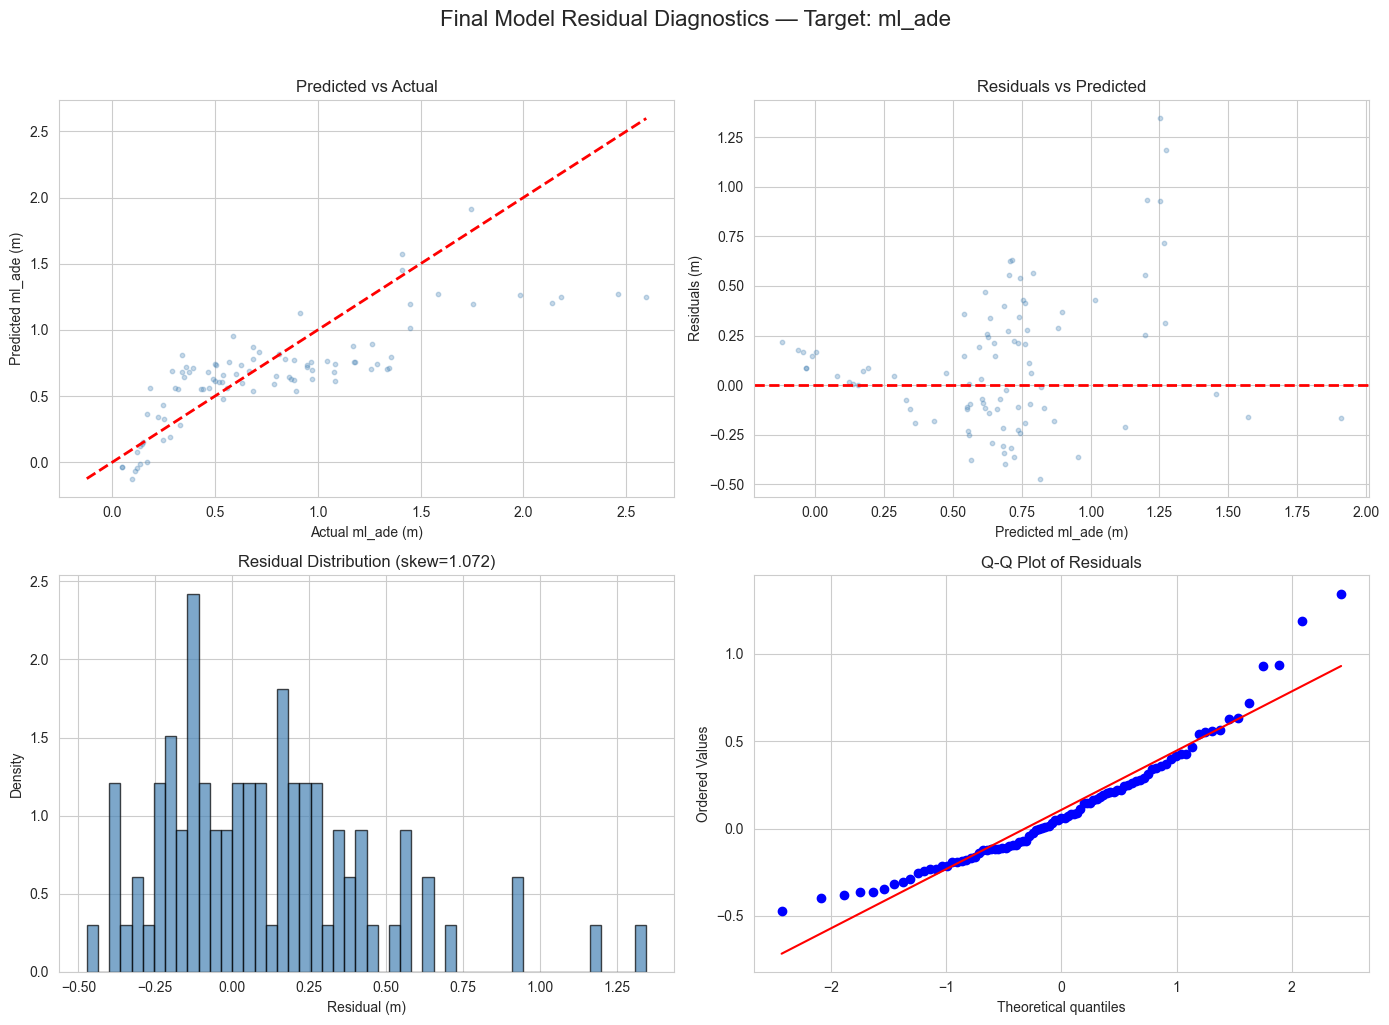


Residual statistics:
  Mean:   0.1071 m
  Std:    0.3433 m
  Median: 0.0600 m
  Skew:   1.0719


In [39]:
# Final residual diagnostics
y_final_pred = linear_gam_reduced.predict(X_test_sig)
if LOG_TRANSFORM:
    y_final_actual = np.expm1(y_test)
    y_final_pred_orig = np.expm1(y_final_pred)
else:
    y_final_actual = y_test
    y_final_pred_orig = y_final_pred

residuals_final = y_final_actual - y_final_pred_orig

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs Actual
axes[0, 0].scatter(y_final_actual, y_final_pred_orig, alpha=0.3, s=10, color="steelblue")
lims = [
    min(y_final_actual.min(), y_final_pred_orig.min()),
    max(y_final_actual.max(), y_final_pred_orig.max())
]
axes[0, 0].plot(lims, lims, "r--", linewidth=2)
axes[0, 0].set_xlabel(f"Actual {target_col} (m)")
axes[0, 0].set_ylabel(f"Predicted {target_col} (m)")
axes[0, 0].set_title("Predicted vs Actual")

# 2. Residuals vs Predicted
axes[0, 1].scatter(y_final_pred_orig, residuals_final, alpha=0.3, s=10, color="steelblue")
axes[0, 1].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel(f"Predicted {target_col} (m)")
axes[0, 1].set_ylabel("Residuals (m)")
axes[0, 1].set_title("Residuals vs Predicted")

# 3. Histogram of residuals
axes[1, 0].hist(residuals_final, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="black")
axes[1, 0].set_xlabel("Residual (m)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title(f"Residual Distribution (skew={skew(residuals_final):.3f})")

# 4. Q-Q plot of residuals
stats.probplot(residuals_final, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals")

plt.suptitle(f"Final Model Residual Diagnostics — Target: {target_col}", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"residual_diagnostics_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nResidual statistics:")
print(f"  Mean:   {residuals_final.mean():.4f} m")
print(f"  Std:    {residuals_final.std():.4f} m")
print(f"  Median: {np.median(residuals_final):.4f} m")
print(f"  Skew:   {skew(residuals_final):.4f}")